# Previsão de demanda de bicicletas compartilhadas em Seul com MLP

**Integrantes da equipe:** Gabriel Albuquerque Alencar, Alberto Eduardo Acosta, Davi Maciel Corrêa

**Disciplina:** Inteligência Computacional / Machine Learning — Profa. Polyana Santos Fonseca Nascimento

## Declaração de uso de IA Generativa

- **Ferramenta utilizada:** Claude (Anthropic), via Claude Code.
- **Finalidade do uso:** apoio na escrita do código e da documentação em Markdown deste notebook: análise exploratória, pipeline de pré-processamento, MLP, Random Search, TPE (Optuna) e comparação entre as buscas. A análise de sensibilidade individual, a avaliação final no teste e a discussão crítica.
- **Extensão aproximada da contribuição:** a IA gerou a maior parte do código e dos textos, a partir de um plano de execução definido com a equipe. As decisões de modelagem foram propostas pela IA e devem ser compreendidas e defendidas por cada integrante.
- **Medidas de validação:** todo o notebook é executado de ponta a ponta com sementes fixas; verificações automáticas (`assert`) garantem que treino e teste não compartilham dias; o conjunto de teste só é usado na avaliação final; os resultados e gráficos são conferidos e interpretados pela equipe.

> O arquivo `SeoulBikeData.csv` é o backup original e nunca é sobrescrito. A limpeza inicial (remoção de `Functioning Day = No` e criação de `IsWeekend`) está documentada em `preprocessing.ipynb` e gerou `SeoulBikeData_treated.csv`, que é a entrada deste notebook.

## 1. Dataset e justificativa

- **Dataset:** *Seoul Bike Sharing Demand* (UCI Machine Learning Repository / Kaggle), com uma observação por hora ao longo de um ano (dez/2017 a nov/2018).
- **Problema:** **regressão**. O alvo é `Rented Bike Count`, o número de bicicletas alugadas por hora.
- **Preditores:** hora do dia, variáveis climáticas (temperatura, umidade, vento, visibilidade, radiação solar, chuva, neve), estação do ano, feriado e fim de semana.
- **Motivação:** prever demanda horária ajuda a operadora a redistribuir bicicletas entre estações. O problema mistura efeitos sazonais, cíclicos (hora) e climáticos, com relações não lineares que justificam uma MLP.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="IProgress not found")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

SEED = 42
TARGET = "Rented Bike Count"
DATA_PATH = "SeoulBikeData_treated.csv"

## 2. Análise inicial dos dados

O arquivo tratado já não tem valores ausentes nem registros com o sistema fechado. Confirmamos o formato, os tipos e a ausência de nulos antes de explorar.

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
print(df.shape)
print("Nulos:", int(df.isnull().sum().sum()), "| Dias distintos:", df["Date"].nunique())
df.head()

(8465, 14)
Nulos: 0 | Dias distintos: 353


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,IsWeekend
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,0


In [3]:
df.drop(columns="Date").describe().T[["mean", "std", "min", "50%", "max"]].round(2)

,mean,std,min,50%,max
Rented Bike Count,729.16,642.35,2.0,542.00,3556.00
Hour,11.51,6.92,0.0,12.00,23.00
Temperature(°C),12.77,12.10,-17.8,13.50,39.40
Humidity(%),58.15,20.48,0.0,57.00,98.00
Wind speed (m/s),1.73,1.03,0.0,1.50,7.40
Visibility (10m),1433.87,609.05,27.0,1690.00,2000.00
Dew point temperature(°C),3.94,13.24,-30.6,4.70,27.20
Solar Radiation (MJ/m2),0.57,0.87,0.0,0.01,3.52
Rainfall(mm),0.15,1.13,0.0,0.00,35.00
Snowfall (cm),0.08,0.44,0.0,0.00,8.80


### 2.1 Variável-alvo

A demanda é sempre positiva e assimétrica à direita: poucas horas concentram volumes muito altos. Comparamos a assimetria (*skewness*) do alvo original com duas transformações candidatas, `sqrt` e `log1p`.

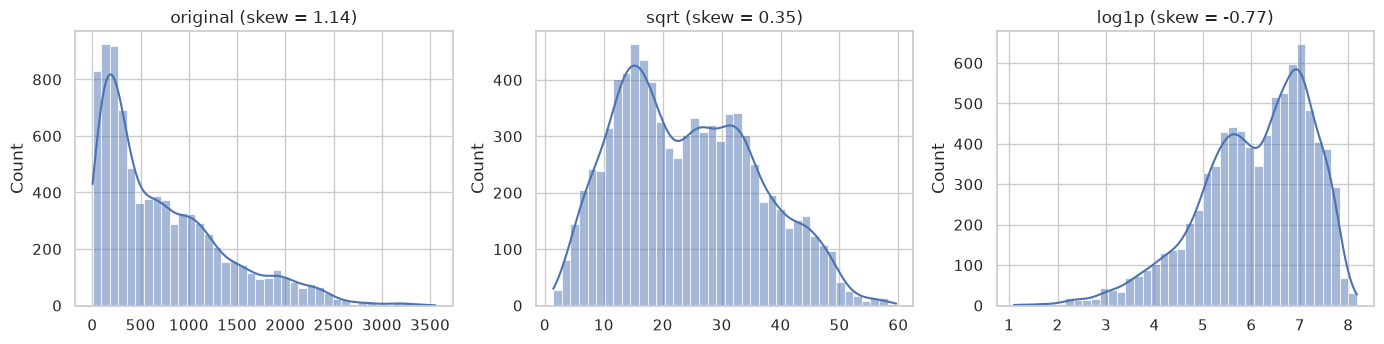

In [4]:
transforms = {"original": lambda s: s, "sqrt": np.sqrt, "log1p": np.log1p}
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, (name, fn) in zip(axes, transforms.items()):
    values = fn(df[TARGET])
    sns.histplot(values, bins=40, kde=True, ax=ax)
    ax.set_title(f"{name} (skew = {values.skew():.2f})")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

`sqrt` aproxima bem a simetria (skew 0,35), enquanto `log1p` supercorrige para o outro lado (−0,77). A transformação do alvo será escolhida experimentalmente na etapa da MLP base. Qualquer que seja ela, as métricas serão sempre reportadas **na escala original** (bicicletas/hora).

### 2.2 Padrões de demanda

A demanda depende fortemente da hora (picos de deslocamento às 8h e 18h), da estação e da chuva. A curva horária é cíclica, o que orienta a codificação de `Hour` mais adiante.

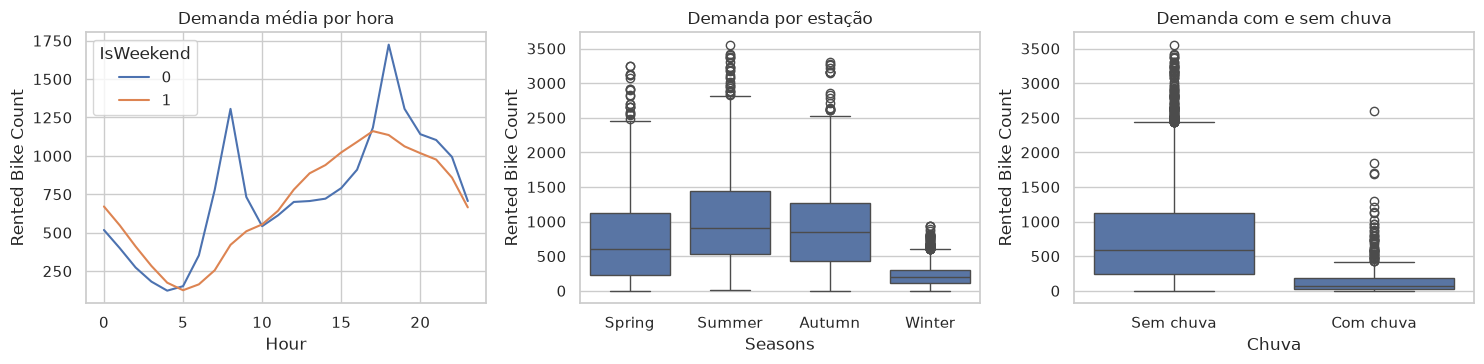

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
sns.lineplot(data=df, x="Hour", y=TARGET, hue="IsWeekend", errorbar=None, ax=axes[0])
axes[0].set_title("Demanda média por hora")
sns.boxplot(data=df, x="Seasons", y=TARGET, order=["Spring", "Summer", "Autumn", "Winter"], ax=axes[1])
axes[1].set_title("Demanda por estação")
rain = df.assign(Chuva=np.where(df["Rainfall(mm)"] > 0, "Com chuva", "Sem chuva"))
sns.boxplot(data=rain, x="Chuva", y=TARGET, ax=axes[2])
axes[2].set_title("Demanda com e sem chuva")
plt.tight_layout()
plt.show()

- **Hora:** em dias úteis há dois picos (8h e 18h), típicos de deslocamento casa-trabalho; no fim de semana há uma curva única e mais suave. A interação hora × fim de semana é um padrão que a MLP deve capturar.
- **Estação:** o inverno tem demanda muito menor.
- **Chuva:** horas com chuva derrubam a demanda.

### 2.3 Escalas e valores atípicos

Os atributos têm escalas muito diferentes (visibilidade na casa dos milhares, chuva e neve em décimos), o que exige padronização para uma MLP. Contamos os valores fora de 1,5×IQR de cada atributo numérico contínuo.

In [6]:
NUMERIC = ["Temperature(°C)", "Humidity(%)", "Wind speed (m/s)", "Visibility (10m)",
           "Solar Radiation (MJ/m2)", "Rainfall(mm)", "Snowfall (cm)"]
q1, q3 = df[NUMERIC].quantile(0.25), df[NUMERIC].quantile(0.75)
iqr = q3 - q1
outliers = ((df[NUMERIC] < q1 - 1.5 * iqr) | (df[NUMERIC] > q3 + 1.5 * iqr)).mean().mul(100).round(1)
pd.DataFrame({"% fora de 1.5×IQR": outliers, "% zeros": (df[NUMERIC] == 0).mean().mul(100).round(1)})

,% fora de 1.5×IQR,% zeros
Temperature(°C),0.0,0.2
Humidity(%),0.0,0.2
Wind speed (m/s),1.8,0.8
Visibility (10m),0.0,0.0
Solar Radiation (MJ/m2),7.3,49.0
Rainfall(mm),6.1,93.9
Snowfall (cm),5.2,94.8


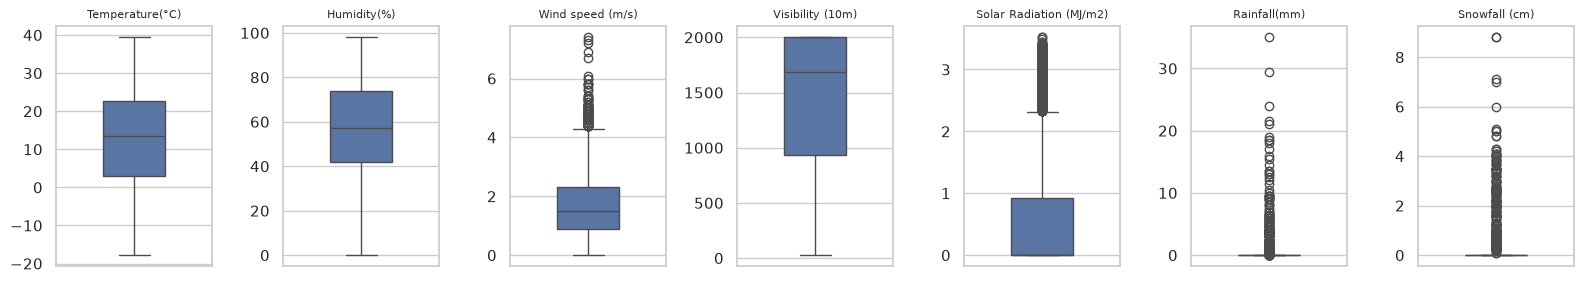

In [7]:
fig, axes = plt.subplots(1, len(NUMERIC), figsize=(16, 3))
for ax, col in zip(axes, NUMERIC):
    sns.boxplot(y=df[col], ax=ax, width=0.4)
    ax.set_ylabel("")
    ax.set_title(col, fontsize=8)
plt.tight_layout()
plt.show()

**Decisão sobre atípicos:** `Rainfall` e `Snowfall` são quase sempre zero (94% e 95%), então os poucos valores altos são eventos climáticos reais, não erros. `Solar Radiation` tem 49% de zeros pela noite. **Mantemos todos os valores**: removê-los eliminaria justamente as horas de baixa demanda que o modelo precisa aprender. A padronização (`StandardScaler`) resolve a diferença de escalas.

### 2.4 Correlações e redundância

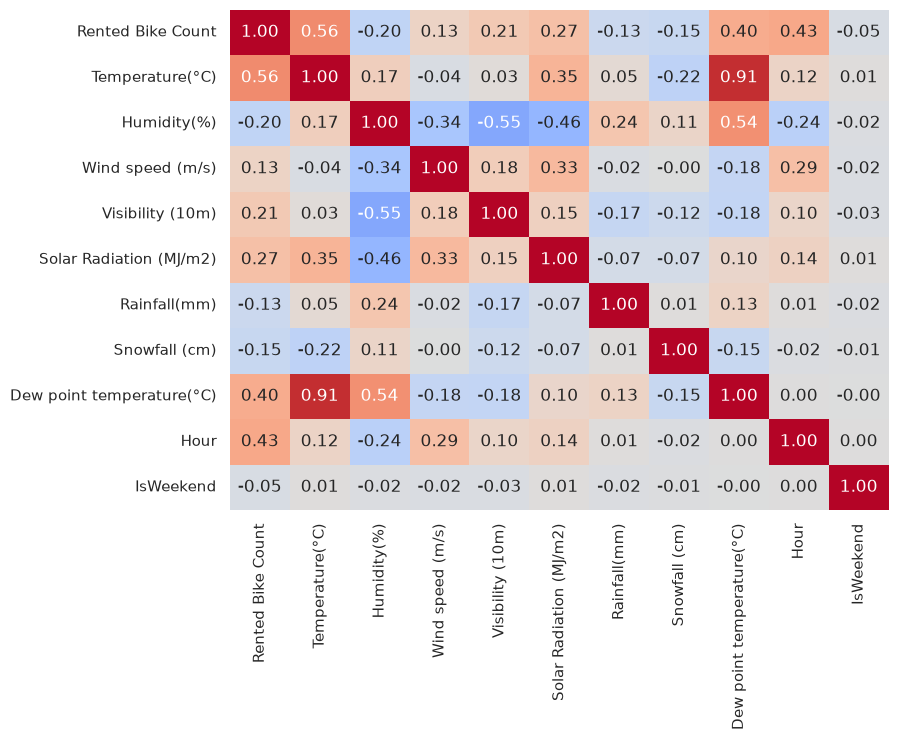

In [8]:
corr = df[[TARGET] + NUMERIC + ["Dew point temperature(°C)", "Hour", "IsWeekend"]].corr()
plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, cbar=False)
plt.show()

`Temperature` e `Dew point temperature` têm correlação de 0,91: carregam praticamente a mesma informação. **Decisão:** remover `Dew point temperature`, mantendo `Temperature`, que tem correlação maior com o alvo e interpretação mais direta. Isso reduz a colinearidade sem perda relevante de informação. `Hour` aparece com correlação linear moderada com o alvo, mas o efeito real é cíclico e não linear, tratado na codificação seno/cosseno.

## 3. Conjunto de teste (holdout) e validação cruzada

### 3.1 Separação treino/teste

Os registros são horários: horas vizinhas do mesmo dia são muito parecidas (mesmo clima, mesma estação). Um sorteio aleatório por linha colocaria horas do mesmo dia em treino e em teste, e o teste ficaria otimista por **vazamento**. Um corte temporal também não serve: com apenas um ano de dados, o teste cairia em uma estação que o treino nunca viu.

**Decisão:** separar por **dia inteiro**, agrupando por `Date`, e **estratificar por estação** para que o teste tenha a mesma mistura de estações do treino (um sorteio simples de 71 dias deixou inverno sobrerrepresentado). Usamos `StratifiedGroupKFold` com 5 partes e tomamos uma delas, cerca de 20% dos dias, como teste. Esse conjunto só volta a ser usado na avaliação final (seção 10).

In [9]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

FEATURES = NUMERIC + ["Hour", "IsWeekend", "Seasons", "Holiday"]

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(splitter.split(df, df["Seasons"], groups=df["Date"]))
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

X_train, y_train, groups_train = train_df[FEATURES], train_df[TARGET], train_df["Date"]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

assert set(train_df["Date"]).isdisjoint(test_df["Date"])

pd.DataFrame({
    "linhas": [len(train_df), len(test_df)],
    "dias": [train_df["Date"].nunique(), test_df["Date"].nunique()],
    "alvo médio": [y_train.mean(), y_test.mean()],
    "alvo mediano": [y_train.median(), y_test.median()],
    "alvo desvio": [y_train.std(), y_test.std()],
}, index=["treino", "teste"]).round(1)

,linhas,dias,alvo médio,alvo mediano,alvo desvio
treino,6761,282,731.1,547.0,640.7
teste,1704,71,721.5,531.5,649.0


In [10]:
season_share = pd.concat([train_df["Seasons"].value_counts(normalize=True).rename("treino"),
                          test_df["Seasons"].value_counts(normalize=True).rename("teste")], axis=1)
season_share.mul(100).round(1)

,treino,teste
Seasons,,
Summer,25.9,26.8
Winter,25.6,25.4
Spring,25.6,25.4
Autumn,23.0,22.5


A estratificação mantém a proporção de estações próxima nos dois conjuntos e o alvo com escala parecida, então o holdout é representativo.

### 3.2 Estratégia de validação cruzada

A validação cruzada usa **apenas o conjunto de treino**, com `StratifiedGroupKFold` de 5 folds embaralhados, agrupados por dia e estratificados por estação. Os folds são gerados **uma única vez** e reutilizados em todos os experimentos (Random Search, TPE, sensibilidade), garantindo comparações justas.

In [11]:
N_SPLITS = 5
cv_splits = list(StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED).split(X_train, X_train["Seasons"], groups_train))

pd.DataFrame([
    {"fold": k + 1, "treino": len(tr), "validação": len(va), "dias na validação": groups_train.iloc[va].nunique()}
    for k, (tr, va) in enumerate(cv_splits)
]).set_index("fold")

,treino,validação,dias na validação
fold,,,
1,5393,1368,57
2,5417,1344,56
3,5400,1361,57
4,5417,1344,56
5,5417,1344,56


## 4. Construção da MLP

### 4.1 Pré-processamento dentro do pipeline

Todas as transformações que aprendem parâmetros dos dados entram em um `Pipeline`, ajustado somente com o treino de cada fold, para não vazar informação da validação:

- `Hour` vira `sin` e `cos` (a hora 23 é vizinha da hora 0);
- atributos contínuos passam por `StandardScaler`;
- `Seasons` e `Holiday` recebem *one-hot*; `IsWeekend` já é binária;
- `Date` e `Dew point temperature` ficam fora, conforme a análise exploratória;
- o alvo é transformado (`sqrt`, `log1p` ou nenhuma) dentro de um `TransformedTargetRegressor`, que devolve as previsões à escala original.

**Métrica principal: RMSE** (bicicletas/hora), que penaliza mais os erros grandes, importantes para dimensionar a frota. MAE e R² são complementares.

In [12]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

MAX_ITER = 300
N_JOBS = N_SPLITS
SCORING = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}
TARGET_TRANSFORMS = {"original": (None, None), "sqrt": (np.sqrt, np.square), "log1p": (np.log1p, np.expm1)}


def add_hour_cycle(X):
    X = X.copy()
    X["hour_sin"] = np.sin(2 * np.pi * X["Hour"] / 24)
    X["hour_cos"] = np.cos(2 * np.pi * X["Hour"] / 24)
    return X.drop(columns="Hour")


def build_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), NUMERIC),
        ("cat", OneHotEncoder(drop="if_binary"), ["Seasons", "Holiday"]),
        ("pass", "passthrough", ["IsWeekend", "hour_sin", "hour_cos"]),
    ])


def build_model(p, seed=SEED, target_transform=None):
    func, inverse = TARGET_TRANSFORMS[target_transform or TARGET_TRANSFORM]
    mlp = MLPRegressor(
        hidden_layer_sizes=(p["n_units"],) * p["n_layers"],
        activation=p["activation"],
        solver=p["solver"],
        learning_rate_init=p["learning_rate"],
        batch_size=p["batch_size"],
        early_stopping=True,
        n_iter_no_change=p["patience"],
        max_iter=MAX_ITER,
        random_state=seed,
    )
    pipeline = Pipeline([
        ("hour", FunctionTransformer(add_hour_cycle)),
        ("prep", build_preprocessor()),
        ("mlp", mlp),
    ])
    return TransformedTargetRegressor(regressor=pipeline, func=func, inverse_func=inverse, check_inverse=False)


memory = joblib.Memory(".cache", verbose=0)


@memory.cache
def cached_cross_validate(p, seed, target_transform, max_iter, X, y, splits):
    return cross_validate(build_model(p, seed, target_transform), X, y, cv=splits,
                          scoring=SCORING, return_train_score=True, n_jobs=N_JOBS)


def cv_evaluate(p, seed=SEED, target_transform=None):
    scores = cached_cross_validate(p, seed, target_transform or TARGET_TRANSFORM, MAX_ITER, X_train, y_train, cv_splits)
    return pd.Series({
        "val_rmse": -scores["test_rmse"].mean(),
        "val_rmse_std": scores["test_rmse"].std(),
        "val_mae": -scores["test_mae"].mean(),
        "val_r2": scores["test_r2"].mean(),
        "train_rmse": -scores["train_rmse"].mean(),
        "train_r2": scores["train_r2"].mean(),
    })

### 4.2 MLP base e escolha da transformação do alvo

Treinamos uma MLP simples e razoável (2 camadas de 64 neurônios, ReLU, Adam, *learning rate* 1e-3, lote de 64, paciência 10) com cada transformação do alvo, avaliando por validação cruzada. A transformação com menor RMSE é fixada para todo o restante do trabalho.

In [13]:
BASELINE = {"n_layers": 2, "n_units": 64, "activation": "relu", "solver": "adam",
            "learning_rate": 1e-3, "batch_size": 64, "patience": 10}

transform_results = pd.DataFrame({name: cv_evaluate(BASELINE, target_transform=name) for name in TARGET_TRANSFORMS}).T
TARGET_TRANSFORM = transform_results["val_rmse"].idxmin()
print("Transformação escolhida:", TARGET_TRANSFORM)
transform_results.round(3)

Transformação escolhida: sqrt


,val_rmse,val_rmse_std,val_mae,val_r2,train_rmse,train_r2
original,201.892,12.116,129.289,0.900,166.673,0.932
sqrt,193.015,13.452,121.862,0.908,147.733,0.946
log1p,227.706,16.483,143.657,0.872,190.652,0.911


A raiz quadrada do alvo vence (RMSE ≈ 193 contra 202 sem transformação). O `log1p` fica pior, pois otimiza erro relativo e subestima os picos de demanda, justamente o que o RMSE em escala original penaliza. A **raiz quadrada** fica fixa daqui em diante.

### 4.3 Comportamento do treino da MLP base

Ajustamos o modelo base em todo o treino (o teste continua intocado) e observamos a curva de perda e a pontuação R² da fatia de validação interna usada pelo *early stopping*.

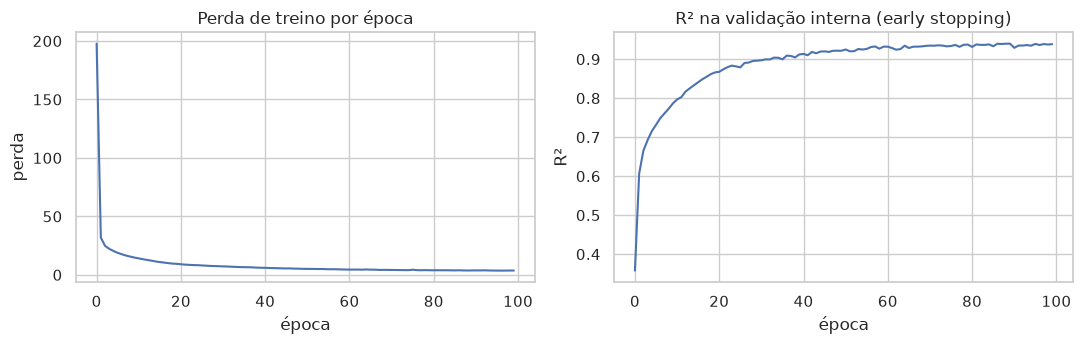

Épocas executadas: 100


In [14]:
base_model = build_model(BASELINE).fit(X_train, y_train)
base_mlp = base_model.regressor_.named_steps["mlp"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(base_mlp.loss_curve_)
axes[0].set(title="Perda de treino por época", xlabel="época", ylabel="perda")
axes[1].plot(base_mlp.validation_scores_)
axes[1].set(title="R² na validação interna (early stopping)", xlabel="época", ylabel="R²")
plt.tight_layout()
plt.show()
print("Épocas executadas:", base_mlp.n_iter_)

A perda cai rapidamente e estabiliza, e o R² de validação interna chega perto de 0,94 sem sinais de divergência. O modelo base já explica cerca de 91% da variância em validação cruzada (R² ≈ 0,91, RMSE ≈ 193 bicicletas/hora), com R² de treino um pouco maior (≈ 0,95). Esse é o ponto de referência a ser melhorado pelas buscas de hiperparâmetros.

## 5. Random Search (baseline de hiperparâmetros)

### 5.1 Espaço de busca

O espaço abaixo é definido **uma única vez** e usado tanto pelo Random Search quanto pelo TPE. As duas buscas também compartilham a mesma função objetivo (RMSE médio na validação cruzada agrupada, sobre o treino), os mesmos folds e o mesmo orçamento de **25 configurações**. A única diferença entre elas é o algoritmo que propõe a próxima configuração.

| Hiperparâmetro | Faixa / opções | Escala | Justificativa |
|---|---|---|---|
| `n_layers` | 1 a 3 | inteiro | ~6,8 mil linhas e 11 atributos: redes mais profundas tendem a sobreajustar |
| `n_units` | 16 a 256 | inteiro, log | mesmo número de neurônios em cada camada oculta |
| `activation` | `relu`, `tanh` | categórica | ativações comuns em regressão tabular |
| `learning_rate` | 1e-4 a 1e-1 | contínua, log | cobre de passos muito pequenos a instáveis |
| `batch_size` | 32, 64, 128, 256 | categórica | de gradiente ruidoso a mais suave |
| `solver` | `adam`, `sgd` | categórica | otimizador adaptativo contra SGD com momento |
| `patience` | 5 a 30 | inteiro | paciência do *early stopping* (fatia de validação interna de 10%) |

In [15]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 25
NO_SKILL_RMSE = float(y_train.std())


def suggest_params(trial):
    return {
        "n_layers": trial.suggest_int("n_layers", 1, 3),
        "n_units": trial.suggest_int("n_units", 16, 256, log=True),
        "activation": trial.suggest_categorical("activation", ["relu", "tanh"]),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128, 256]),
        "solver": trial.suggest_categorical("solver", ["adam", "sgd"]),
        "patience": trial.suggest_int("patience", 5, 30),
    }


def objective(trial):
    result = cv_evaluate(suggest_params(trial))
    for key in ("val_rmse_std", "val_mae", "val_r2", "train_rmse", "train_r2"):
        trial.set_user_attr(key, float(result[key]))
    rmse = float(result["val_rmse"])
    return min(rmse, NO_SKILL_RMSE) if np.isfinite(rmse) else NO_SKILL_RMSE


def run_search(sampler):
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_TRIALS)
    return study


def trials_table(study):
    rows = [{"trial": t.number, **t.params, "val_rmse": t.value, **t.user_attrs} for t in study.trials]
    return pd.DataFrame(rows).set_index("trial")

### 5.2 Execução

Configurações que divergem numericamente (por exemplo, SGD com *learning rate* alto) geram previsões absurdas ou inválidas. Para que uma delas não distorça a busca, o RMSE de qualquer configuração é limitado ao de um preditor que sempre responde a média do treino (o desvio padrão do alvo, ≈ 641): nenhuma configuração é pior que "não aprender nada".

In [16]:
random_study = run_search(optuna.samplers.RandomSampler(seed=SEED))
random_trials = trials_table(random_study)
random_trials.sort_values("val_rmse").head(5).round(4)

,n_layers,n_units,activation,learning_rate,batch_size,solver,patience,val_rmse,val_rmse_std,val_mae,val_r2,train_rmse,train_r2
trial,,,,,,,,,,,,,
0,2,223,relu,0.0003,128,adam,30,184.8440,19.0251,115.6187,0.9149,129.9694,0.9587
1,3,28,tanh,0.0008,256,sgd,14,185.5464,22.2064,114.8375,0.9138,143.8492,0.9494
13,3,131,tanh,0.0013,64,adam,9,185.8504,14.8606,114.7932,0.9145,124.9388,0.9618
22,3,124,tanh,0.0012,256,adam,18,185.9566,17.5280,114.8359,0.9139,123.8533,0.9620
6,1,153,tanh,0.0206,256,adam,6,190.1153,20.9062,119.5183,0.9098,147.5690,0.9467


In [17]:
best_random = random_study.best_trial
print(f"Melhor trial: {best_random.number} | RMSE CV = {best_random.value:.2f} ± {best_random.user_attrs['val_rmse_std']:.2f}")
print("Configurações limitadas pelo preditor constante:", int((random_trials["val_rmse"] >= NO_SKILL_RMSE).sum()))
random_trials.sort_values("val_rmse")[["n_layers", "n_units", "activation", "solver", "learning_rate", "val_rmse"]].round(4).T

Melhor trial: 0 | RMSE CV = 184.84 ± 19.03
Configurações limitadas pelo preditor constante: 3


trial,0,1,13,22,6,2,10,20,15,19,5,18,4,17,24,8,11,14,12,16,21,3,9,7,23
n_layers,2,3,3,3,1,2,3,3,2,3,2,1,2,2,1,2,1,1,1,3,3,1,1,1,3
n_units,223,28,131,124,153,140,192,225,21,91,33,126,26,16,81,51,40,81,17,92,38,20,19,39,96
activation,relu,tanh,tanh,tanh,tanh,tanh,relu,relu,relu,relu,relu,tanh,relu,tanh,tanh,tanh,relu,relu,relu,tanh,tanh,relu,relu,relu,tanh
solver,adam,sgd,adam,adam,adam,sgd,adam,adam,adam,sgd,adam,sgd,adam,sgd,sgd,sgd,sgd,sgd,sgd,sgd,adam,adam,sgd,sgd,sgd
learning_rate,0.0003,0.0008,0.0013,0.0012,0.0206,0.006,0.0005,0.0001,0.0006,0.0054,0.0007,0.0094,0.0658,0.0001,0.0294,0.0001,0.0036,0.0034,0.0001,0.0151,0.0643,0.0002,0.0615,0.0459,0.0468
val_rmse,184.844,185.5464,185.8504,185.9566,190.1153,193.9005,194.6964,195.3946,196.8669,197.3066,197.4421,199.6816,200.6,201.9369,206.4164,207.388,216.1325,216.1732,239.0857,358.5621,359.6791,362.5885,640.6921,640.6921,640.6921


### 5.3 Resultados do Random Search

A melhor configuração (trial 0) usa 2 camadas de 223 neurônios, ReLU, Adam, *learning rate* 3e-4, lote de 128 e paciência 30, com **RMSE de validação cruzada de 184,8 ± 19,0**, cerca de 4% melhor que a MLP base (193,0).

- As quatro melhores configurações ficam entre 184,8 e 186,0, diferença bem menor que o desvio entre folds (15 a 22). Na prática, estão **empatadas**.
- Três configurações (todas SGD com *learning rate* acima de 0,045) divergiram e foram limitadas ao preditor constante.
- Adam domina o topo da tabela, e o SGD só funciona em faixas restritas de *learning rate*.

## 6. Busca adaptativa com TPE (Optuna)

O TPE (*Tree-structured Parzen Estimator*) modela separadamente a densidade das configurações **boas** e das **ruins** já observadas e propõe a próxima configuração onde a razão entre elas é favorável. Assim, a busca concentra esforço nas regiões promissoras do espaço, ao contrário do Random Search, que sorteia sem memória.

Para a comparação ser válida, nada muda além do amostrador: mesmo espaço (`suggest_params`), mesma função objetivo, mesmos folds, mesma métrica e **25 trials**. O TPE do Optuna usa por padrão os 10 primeiros trials como amostragem aleatória de partida (com a mesma semente do Random Search, o que será examinado na seção 7).

In [18]:
tpe_study = run_search(optuna.samplers.TPESampler(seed=SEED))
tpe_trials = trials_table(tpe_study)
tpe_trials.sort_values("val_rmse").head(5).round(4)

,n_layers,n_units,activation,learning_rate,batch_size,solver,patience,val_rmse,val_rmse_std,val_mae,val_r2,train_rmse,train_r2
trial,,,,,,,,,,,,,
0,2,223,relu,0.0003,128,adam,30,184.8440,19.0251,115.6187,0.9149,129.9694,0.9587
21,3,78,tanh,0.0018,256,sgd,19,185.0713,23.0725,113.5102,0.9143,125.1307,0.9615
1,3,28,tanh,0.0008,256,sgd,14,185.5464,22.2064,114.8375,0.9138,143.8492,0.9494
11,3,93,tanh,0.0015,256,sgd,20,188.6132,14.5035,115.2707,0.9119,136.7879,0.9539
6,1,153,tanh,0.0206,256,adam,6,190.1153,20.9062,119.5183,0.9098,147.5690,0.9467


In [19]:
best_tpe = tpe_study.best_trial
print(f"Melhor trial: {best_tpe.number} | RMSE CV = {best_tpe.value:.2f} ± {best_tpe.user_attrs['val_rmse_std']:.2f}")
print("Configurações limitadas pelo preditor constante:", int((tpe_trials["val_rmse"] >= NO_SKILL_RMSE).sum()))
pd.Series(best_tpe.params, name="melhor configuração (TPE)").to_frame()

Melhor trial: 0 | RMSE CV = 184.84 ± 19.03
Configurações limitadas pelo preditor constante: 2


,melhor configuração (TPE)
n_layers,2
n_units,223
activation,relu
learning_rate,0.000294
batch_size,128
solver,adam
patience,30


### 6.1 Evolução da busca

Cada ponto é um trial. A linha mostra o melhor RMSE obtido até aquele momento. A linha vertical tracejada marca o fim da fase de partida aleatória do TPE. Trials com RMSE acima de 400 (configurações divergentes) ficam fora do eixo.

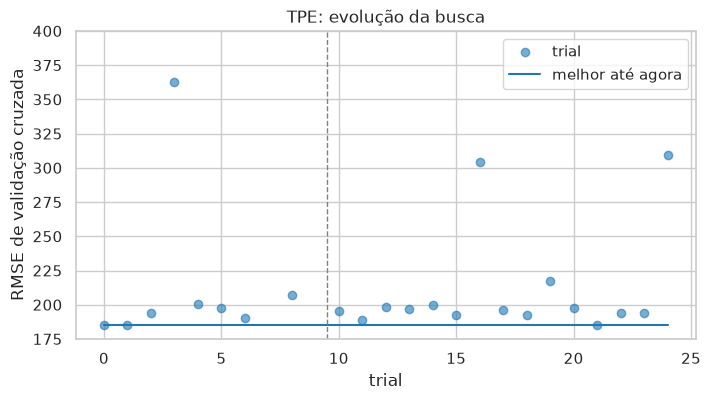

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(tpe_trials.index, tpe_trials["val_rmse"], color="tab:blue", alpha=0.6, label="trial")
ax.step(tpe_trials.index, tpe_trials["val_rmse"].cummin(), where="post", color="tab:blue", label="melhor até agora")
ax.axvline(9.5, color="gray", linestyle="--", linewidth=1)
ax.set(ylim=(175, 400), xlabel="trial", ylabel="RMSE de validação cruzada", title="TPE: evolução da busca")
ax.legend()
plt.show()

### 6.2 Importância dos hiperparâmetros

A importância é estimada pelo Optuna a partir dos 25 trials (avaliador padrão, fANOVA). Com tão poucos trials, deve ser lida como indicativa.

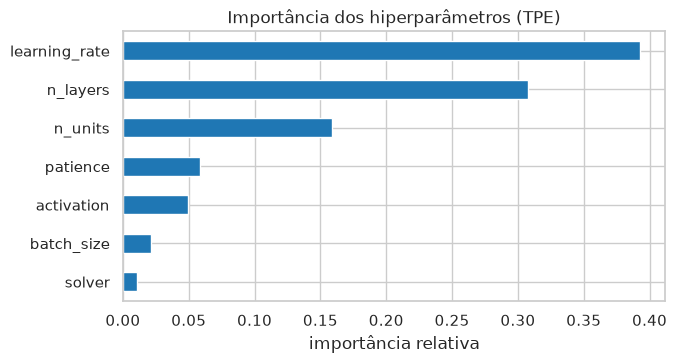

,importância
learning_rate,0.392
n_layers,0.308
n_units,0.159
patience,0.059
activation,0.050
batch_size,0.022
solver,0.011


In [21]:
importances = pd.Series(optuna.importance.get_param_importances(tpe_study)).sort_values()
importances.plot.barh(figsize=(7, 3.5), color="tab:blue")
plt.xlabel("importância relativa")
plt.title("Importância dos hiperparâmetros (TPE)")
plt.show()
importances.sort_values(ascending=False).round(3).to_frame("importância")

### 6.3 Resultados do TPE

- O melhor trial (RMSE de validação cruzada **184,8 ± 19,0**) é o trial 0, que pertence à fase de partida aleatória. Entre os 15 trials guiados pelo TPE, o melhor foi o trial 21 (3 camadas de 78 neurônios, `tanh`, SGD, *learning rate* 1,8e-3), com RMSE 185,1, praticamente igual ao melhor.
- **Importância estimada:** *learning rate* (0,39), número de camadas (0,31) e número de neurônios (0,16) explicam a maior parte da variação do desempenho. `batch_size`, `solver` e `patience` pesam pouco. Como o espaço tem 7 hiperparâmetros e só 25 trials, a estimativa é aproximada.

## 7. Comparação entre Random Search e TPE

Com a mesma semente, o amostrador de partida do TPE gera as mesmas configurações que o Random Search nos 10 primeiros trials. Confirmamos isso abaixo. Se for verdade, a diferença entre as estratégias só pode aparecer nos **15 trials finais**, onde o TPE passa a ser guiado pelos resultados anteriores.

In [22]:
PARAM_COLS = list(BASELINE)
START = 10
same_start = random_trials.loc[:START - 1, PARAM_COLS].equals(tpe_trials.loc[:START - 1, PARAM_COLS])
print("Os 10 primeiros trials são idênticos nas duas buscas:", same_start)

Os 10 primeiros trials são idênticos nas duas buscas: True


In [23]:
def summarize(trials):
    tail = trials.loc[START:, "val_rmse"]
    return pd.Series({
        "melhor RMSE (25 trials)": trials["val_rmse"].min(),
        "trial do melhor": trials["val_rmse"].idxmin(),
        "melhor RMSE nos trials 10-24": tail.min(),
        "mediana do RMSE nos trials 10-24": tail.median(),
        "trials 10-24 com RMSE < 200": int((tail < 200).sum()),
        "trials 10-24 muito ruins (RMSE > 300)": int((tail > 300).sum()),
    })


pd.DataFrame({"Random Search": summarize(random_trials), "TPE": summarize(tpe_trials)}).round(1)

,Random Search,TPE
melhor RMSE (25 trials),184.8,184.8
trial do melhor,0.0,0.0
melhor RMSE nos trials 10-24,185.9,185.1
mediana do RMSE nos trials 10-24,201.9,196.5
trials 10-24 com RMSE < 200,7.0,12.0
trials 10-24 muito ruins (RMSE > 300),3.0,2.0


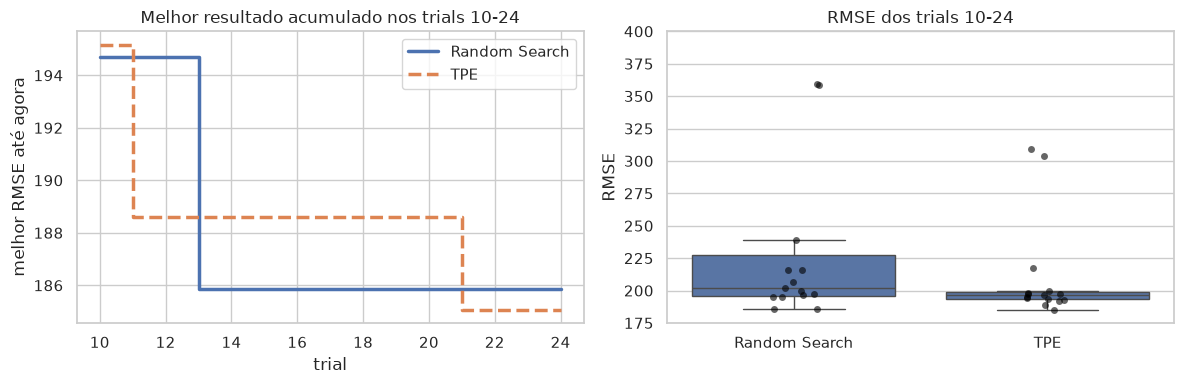

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, trials, style in [("Random Search", random_trials, "-"), ("TPE", tpe_trials, "--")]:
    guided = trials.loc[START:, "val_rmse"]
    axes[0].step(guided.index, guided.cummin(), where="post", label=name, linestyle=style, linewidth=2.5)
axes[0].set(xlabel="trial", ylabel="melhor RMSE até agora", title="Melhor resultado acumulado nos trials 10-24")
axes[0].legend()

tail = pd.concat([
    pd.DataFrame({"estratégia": "Random Search", "RMSE": random_trials.loc[START:, "val_rmse"]}),
    pd.DataFrame({"estratégia": "TPE", "RMSE": tpe_trials.loc[START:, "val_rmse"]}),
])
sns.boxplot(data=tail, x="estratégia", y="RMSE", showfliers=False, ax=axes[1])
sns.stripplot(data=tail, x="estratégia", y="RMSE", color="black", alpha=0.6, ax=axes[1])
axes[1].set(ylim=(175, 400), xlabel="", title="RMSE dos trials 10-24")
plt.tight_layout()
plt.show()

### 7.1 Discussão

- **Qual encontrou a melhor configuração?** As duas chegaram à mesma: o trial 0 (RMSE 184,8). Isso é consequência do desenho, pois a partida aleatória do TPE é idêntica à do Random Search. O melhor global, portanto, não distingue as estratégias.
- **Diferença na fase guiada (trials 10 a 24):** o TPE obteve mediana de RMSE de 196,5 contra 201,9 do Random Search, e 12 dos 15 trials abaixo de 200 contra 7. Também teve menos configurações muito ruins (2 contra 3). Os trials do TPE ficam concentrados em torno de 195 a 200: ele passa a explorar a região promissora, enquanto o Random Search continua espalhado por todo o espaço.
- **Melhor trial guiado:** 185,1 (TPE) contra 185,9 (Random Search). A diferença é muito menor que o desvio entre folds (~19).
- **Ressalva:** com uma única semente por estratégia e 25 trials, a evidência é sugestiva, não conclusiva. O ganho do TPE aparece na **consistência** dos trials, não em uma configuração final melhor.

A configuração escolhida para as etapas seguintes é o trial 0, comum às duas buscas.

## 8. Síntese da etapa 1

| Etapa | Resultado |
|---|---|
| Dados | 8.465 registros horários, 11 preditores; `Dew point temperature` removida por colinearidade (0,91 com `Temperature`); atípicos mantidos |
| Holdout e validação | 6.761 linhas de treino e 1.704 de teste, separadas por dia; teste fora de toda a busca; validação cruzada agrupada de 5 folds só sobre o treino |
| Alvo | raiz quadrada (RMSE 193 contra 202 sem transformação); métricas sempre em bicicletas/hora |
| MLP base | 2 x 64, ReLU, Adam: RMSE de validação cruzada 193,0, R² ≈ 0,91 |
| Melhor configuração (Random Search e TPE) | 2 x 223, ReLU, Adam, lr 3e-4, lote 128, paciência 30: RMSE 184,8 ± 19,0, MAE 115,6, R² 0,915 |
| Random Search × TPE | mesmo melhor trial; na fase guiada o TPE foi mais consistente (mediana 196,5 contra 201,9) |

**Sinais de overfitting:** a configuração escolhida tem RMSE de 130 no treino contra 185 na validação cruzada (R² de 0,959 contra 0,915). A rede ajusta o treino melhor do que generaliza, mas a validação é alta e o *early stopping* limita o excesso. É um sobreajuste moderado, sem sinal de subajuste.

As próximas etapas (seções 9 a 11) fazem a sensibilidade individual, o treino final com avaliação no teste e a discussão crítica.

## 9. Análise de sensibilidade individual

Partindo da melhor configuração (`best_tpe`), cada integrante varia **um** hiperparâmetro, com pelo menos 5 valores, mantendo os outros seis fixos. A métrica é a mesma das buscas (RMSE médio na validação cruzada agrupada, sobre o treino, com os mesmos folds e a mesma semente). O teste continua intocado. A barra de erro é o desvio padrão entre folds.

| Integrante | Hiperparâmetro |
|---|---|
| Gabriel Albuquerque Alencar | `learning_rate` |
| Alberto Eduardo Acosta | `n_layers` |
| Davi Maciel Corrêa | `n_units` |

In [25]:
BEST = dict(best_tpe.params)


def sensitivity(param, values):
    rows = []
    for v in values:
        r = cv_evaluate({**BEST, param: v})
        rows.append({param: v, "RMSE CV": min(r["val_rmse"], NO_SKILL_RMSE), "desvio": r["val_rmse_std"],
                     "MAE CV": r["val_mae"], "R² CV": r["val_r2"], "RMSE treino": r["train_rmse"]})
    return pd.DataFrame(rows).set_index(param)


def plot_sensitivity(table, param, xlabel, log_x=False):
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.errorbar(table.index, table["RMSE CV"], yerr=table["desvio"], marker="o", capsize=4, label="validação cruzada")
    ax.plot(table.index, table["RMSE treino"], marker="s", linestyle="--", color="gray", label="treino")
    ax.axvline(BEST[param], color="tab:red", linestyle=":", label=f"melhor config. ({BEST[param]:.3g})")
    if log_x:
        ax.set_xscale("log")
    ax.set(xlabel=xlabel, ylabel="RMSE (bicicletas/hora)", title=f"Sensibilidade a {param}")
    ax.legend()
    plt.show()

### 9.1 `learning_rate` — Gabriel Albuquerque Alencar

Sete valores, de 1e-4 a 3e-2 em escala logarítmica, incluindo o da melhor configuração (3e-4).

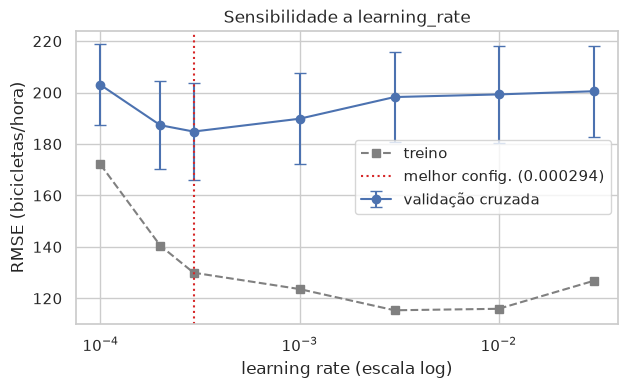

,RMSE CV,desvio,MAE CV,R² CV,RMSE treino
learning_rate,,,,,
0.000100,203.0011,15.7762,128.3893,0.8975,172.0756
0.000200,187.3040,17.2050,117.5914,0.9127,140.4570
0.000294,184.8440,19.0251,115.6187,0.9149,129.9694
0.001000,189.8251,17.7108,119.7310,0.9103,123.6124
0.003000,198.2615,17.6207,122.3300,0.9023,115.3614
0.010000,199.2857,18.8902,121.8642,0.9020,115.9380
0.030000,200.5170,17.6134,125.6433,0.9009,126.7967


In [26]:
lr_values = [1e-4, 2e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2]
lr_sens = sensitivity("learning_rate", [BEST["learning_rate"] if v == 3e-4 else v for v in lr_values])
plot_sensitivity(lr_sens, "learning_rate", "learning rate (escala log)", log_x=True)
lr_sens.round(4)

**Interpretação (Gabriel).** O RMSE tem forma de "U" suave em torno de 3e-4 (184,8). Com 1e-4 o RMSE de validação sobe para 203,0 e o de treino também (172): a rede aprende devagar demais e, com o *early stopping* e o limite de 300 épocas, para antes de convergir, um caso de **subajuste**. Acima de 1e-3 o RMSE de validação sobe para 198 a 201, enquanto o de treino cai para 115 a 116, ou seja, a rede ajusta melhor o treino e generaliza pior (**sobreajuste** e passos maiores que tornam a otimização mais ruidosa). A faixa 2e-4 a 1e-3 é a região boa (185 a 190). A amplitude total é de cerca de 18 bicicletas/hora, e a diferença entre 3e-4 e 2e-4 (2,5) é menor que o desvio entre folds (~17 a 19), então o ponto ótimo exato não é bem determinado, mas a região é.

### 9.2 `n_layers` — Alberto Eduardo Acosta

Cinco valores, de 1 a 5 camadas ocultas, todas com 223 neurônios.

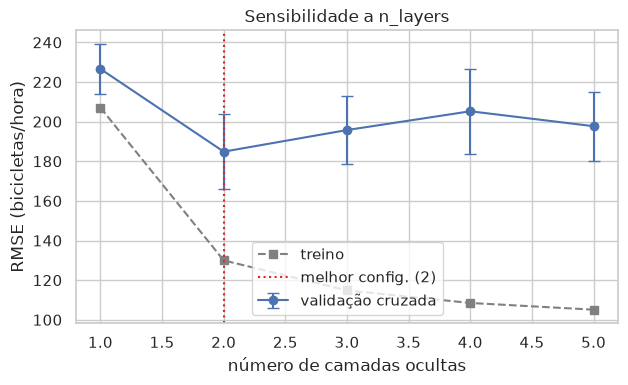

,RMSE CV,desvio,MAE CV,R² CV,RMSE treino
n_layers,,,,,
1,226.6011,12.7353,144.7466,0.8728,207.0672
2,184.8440,19.0251,115.6187,0.9149,129.9694
3,195.7477,17.1341,123.0934,0.9053,114.8165
4,205.2243,21.3830,126.3582,0.8955,108.4846
5,197.6892,17.3100,123.3346,0.9035,105.1045


In [27]:
layers_sens = sensitivity("n_layers", [1, 2, 3, 4, 5])
plot_sensitivity(layers_sens, "n_layers", "número de camadas ocultas")
layers_sens.round(4)

**Interpretação (Alberto).** Uma única camada é claramente insuficiente (RMSE 226,6, treino 207): o modelo não captura as interações entre hora, estação e clima, um **subajuste**. Com 2 camadas o RMSE cai para 184,8. Acima disso o RMSE de treino continua caindo (130, 115, 108, 105), mas o de validação **não melhora** (195,7; 205,2; 197,7): a capacidade extra vira memorização do treino e o intervalo entre treino e validação aumenta de 55 para mais de 90. A curva de validação não é monotônica entre 3 e 5 camadas (o valor de 4 camadas é pior que o de 5), o que reflete o ruído de uma única semente e não uma tendência real. A conclusão robusta é: **1 camada subajusta, 2 é o melhor ponto, mais que 2 sobreajusta**.

### 9.3 `n_units` — Davi Maciel Corrêa

Seis valores, de 16 a 256 neurônios por camada, incluindo o da melhor configuração (223).

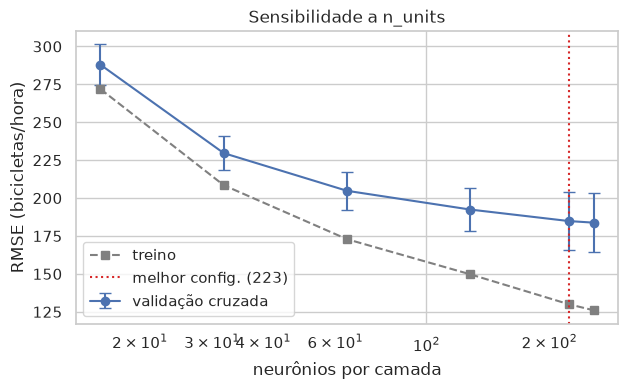

,RMSE CV,desvio,MAE CV,R² CV,RMSE treino
n_units,,,,,
16,287.9658,13.4618,183.7271,0.7944,271.9047
32,229.6651,11.3945,145.0664,0.8699,208.5053
64,204.8083,12.5569,130.0478,0.8961,172.9025
128,192.4366,14.0747,122.3881,0.9084,149.7375
223,184.8440,19.0251,115.6187,0.9149,129.9694
256,183.8088,19.6173,115.1771,0.9160,126.0268


In [28]:
units_sens = sensitivity("n_units", [16, 32, 64, 128, BEST["n_units"], 256])
plot_sensitivity(units_sens, "n_units", "neurônios por camada", log_x=True)
units_sens.round(4)

**Interpretação (Davi).** É o hiperparâmetro com o efeito mais forte na faixa testada: o RMSE cai de 288 (16 neurônios) para 230 (32), 205 (64), 192 (128) e 185 (223). Redes estreitas **subajustam** (treino 272 com 16 neurônios, quase igual à validação) e o ganho vai diminuindo até formar um patamar: de 223 para 256 o RMSE muda só 1,0 (183,8 contra 184,8), muito menos que o desvio entre folds, então os dois valores são equivalentes. Diferente das camadas e do *learning rate*, aumentar neurônios não mostrou piora na validação dentro da faixa, apenas retorno decrescente; o custo é de treino mais lento e maior diferença entre treino e validação (126 contra 184 em 256).

### 9.4 Comparação entre os três hiperparâmetros

Amplitude do RMSE de validação cruzada ao percorrer cada faixa testada, para comparar diretamente com a importância estimada pelo TPE.

In [29]:
sens_summary = pd.DataFrame({
    "integrante": ["Gabriel", "Alberto", "Davi"],
    "hiperparâmetro": ["learning_rate", "n_layers", "n_units"],
    "melhor RMSE": [t["RMSE CV"].min() for t in (lr_sens, layers_sens, units_sens)],
    "pior RMSE": [t["RMSE CV"].max() for t in (lr_sens, layers_sens, units_sens)],
}).set_index("hiperparâmetro")
sens_summary["amplitude"] = sens_summary["pior RMSE"] - sens_summary["melhor RMSE"]
sens_summary["importância TPE"] = importances.reindex(sens_summary.index)
sens_summary.round(3)

,integrante,melhor RMSE,pior RMSE,amplitude,importância TPE
hiperparâmetro,,,,,
learning_rate,Gabriel,184.844,203.001,18.157,0.392
n_layers,Alberto,184.844,226.601,41.757,0.308
n_units,Davi,183.809,287.966,104.157,0.159


**Leitura conjunta.** As três análises mostram o mesmo padrão: o desempenho piora tanto por falta de capacidade (poucas camadas ou neurônios, *learning rate* baixo demais) quanto por excesso (mais camadas, *learning rate* alto), e a melhor configuração fica em uma região intermediária.

Em amplitude bruta, `n_units` (104) > `n_layers` (42) > `learning_rate` (18), o que **não** reproduz a ordem do TPE (`learning_rate` 0,39 > `n_layers` 0,31 > `n_units` 0,16). A comparação será discutida na seção 11.

## 10. Treino final e avaliação no teste

A configuração escolhida é treinada em **todo o treino** (6.761 linhas) e avaliada uma única vez no conjunto de teste (1.704 linhas, 20% dos dias), que não foi usado em nenhuma busca, análise ou decisão. Como uma rede treinada com uma única semente pode variar, repetimos o treino com cinco sementes para medir essa oscilação. O número principal é o da semente 42, a mesma das buscas.

In [30]:
def test_metrics(model):
    pred = model.predict(X_test)
    return {"RMSE": float(np.sqrt(mean_squared_error(y_test, pred))),
            "MAE": float(mean_absolute_error(y_test, pred)), "R²": float(r2_score(y_test, pred))}


final_model = build_model(BEST, seed=SEED).fit(X_train, y_train)
final_pred = final_model.predict(X_test)
test_main = test_metrics(final_model)
cv_ref = cv_evaluate(BEST)

seed_runs = pd.DataFrame([test_metrics(build_model(BEST, seed=s).fit(X_train, y_train)) for s in range(5)],
                         index=[f"semente {s}" for s in range(5)])

pd.DataFrame({
    "treino (ajuste final)": {"RMSE": float(np.sqrt(mean_squared_error(y_train, final_model.predict(X_train)))),
                              "MAE": float(mean_absolute_error(y_train, final_model.predict(X_train))),
                              "R²": float(r2_score(y_train, final_model.predict(X_train)))},
    "validação cruzada": {"RMSE": cv_ref["val_rmse"], "MAE": cv_ref["val_mae"], "R²": cv_ref["val_r2"]},
    "teste (semente 42)": test_main,
    "teste (5 sementes, média)": seed_runs.mean(),
    "teste (5 sementes, desvio)": seed_runs.std(),
}).round(3)

,treino (ajuste final),validação cruzada,teste (semente 42),"teste (5 sementes, média)","teste (5 sementes, desvio)"
RMSE,130.473,184.844,200.490,201.920,3.557
MAE,79.557,115.619,122.903,122.679,2.353
R²,0.959,0.915,0.905,0.903,0.003


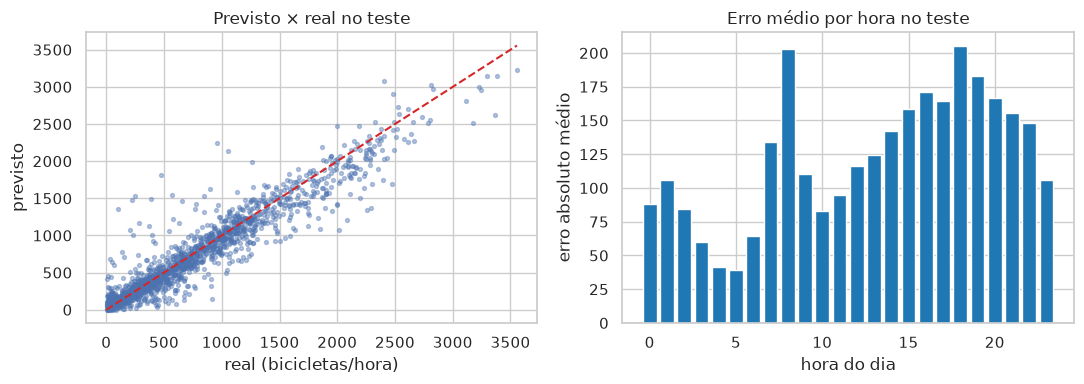

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, final_pred, s=8, alpha=0.4)
lim = [0, max(y_test.max(), final_pred.max())]
axes[0].plot(lim, lim, color="tab:red", linestyle="--")
axes[0].set(xlabel="real (bicicletas/hora)", ylabel="previsto", title="Previsto × real no teste")
hourly = pd.DataFrame({"Hour": X_test["Hour"], "erro absoluto": np.abs(y_test - final_pred)}).groupby("Hour")["erro absoluto"].mean()
axes[1].bar(hourly.index, hourly.values, color="tab:blue")
axes[1].set(xlabel="hora do dia", ylabel="erro absoluto médio", title="Erro médio por hora no teste")
plt.tight_layout()
plt.show()

**Resultado no teste.** A MLP final obtém RMSE de **200,5**, MAE de **122,9** e R² de **0,905** no teste, contra 184,8, 115,6 e 0,915 na validação cruzada. Com cinco sementes, o RMSE de teste tem média 201,9 e desvio de 3,6, então o valor de 200,5 não é um acaso da semente. O desempenho no teste é cerca de 8% pior em RMSE que o estimado na validação cruzada, e o R² cai um ponto. O gráfico mostra previsões concentradas em torno da diagonal, com dispersão crescente com a demanda e tendência a **subestimar** os picos mais altos (acima de ~2.500 bicicletas/hora). O erro absoluto médio por hora é máximo às 8h e às 18h (≈ 200 bicicletas/hora), os picos de deslocamento, e mínimo de madrugada (≈ 40 às 4h e 5h), quando a demanda é baixa.

## 11. Discussão crítica e conclusões

### 11.1 Overfitting e underfitting

| Conjunto | RMSE | R² |
|---|---|---|
| Treino | 130,5 | 0,959 |
| Validação cruzada | 184,8 | 0,915 |
| Teste | 200,5 | 0,905 |

- **Não há subajuste:** o R² é 0,905 no teste e o erro é pequeno frente ao desvio do alvo (≈ 641). O subajuste só apareceu nas variações extremas da sensibilidade (1 camada, 16 neurônios, *learning rate* 1e-4).
- **Há sobreajuste moderado:** o RMSE cresce de 130 (treino) para 185 (validação) e 200 (teste). O *early stopping* e a busca de hiperparâmetros seguram o excesso, mas a rede ajusta o treino bem melhor do que generaliza.
- **O teste ficou pior que a validação cruzada.** O 8% de diferença é maior que o desvio entre sementes (3,6), mas é do tamanho do desvio entre folds (19), e o teste é um único conjunto de 71 dias. Duas causas plausíveis, que este experimento não separa: a variação natural entre conjuntos de dias e o viés de escolher o melhor de 50 trials avaliados na mesma validação (a estimativa do vencedor tende a ser otimista). O valor honesto a reportar como desempenho esperado é o do teste, **RMSE ≈ 200 bicicletas/hora**.

### 11.2 Sensibilidade individual e importância do TPE

| Hiperparâmetro | Importância TPE | Amplitude da sensibilidade | Padrão observado |
|---|---|---|---|
| `learning_rate` | 0,39 (1º) | 18 | "U" suave; ótimo em 2e-4 a 1e-3 |
| `n_layers` | 0,31 (2º) | 42 | 2 camadas é o melhor ponto; 1 subajusta, 3 ou mais sobreajustam |
| `n_units` | 0,16 (3º) | 104 | melhora até ~128 e depois patamar |

A coerência é **parcial**. Coincidem no essencial: os três hiperparâmetros são de fato os que mais movem o RMSE, e `n_layers` e `learning_rate` têm efeitos não monotônicos, com região ótima intermediária. Divergem na ordem, e há razões metodológicas para isso, não necessariamente um erro de um dos lados:

- A sensibilidade é **unidimensional e local**: varia um hiperparâmetro com os outros no melhor ponto. O fANOVA do TPE mede a variância explicada em todo o espaço, incluindo interações e configurações ruins (como SGD com *learning rate* alto), onde o *learning rate* pesa muito e que a análise local não visita.
- A amplitude depende da faixa escolhida. `n_units` de 16 a 32 produz o efeito enorme, mas de 128 a 256 a variação é de 8. Restrita à região boa, sua importância é pequena, como o TPE indica.
- Com 25 trials, a importância do TPE é uma estimativa ruidosa, e cada ponto da sensibilidade vem de uma única semente.

### 11.3 Random Search × TPE

Com o mesmo orçamento (25 trials), os dois chegaram à **mesma melhor configuração**, porque a fase inicial do TPE é idêntica à do Random Search. A vantagem do TPE apareceu na fase guiada, como maior consistência (mediana 196,5 contra 201,9, 12 contra 7 trials abaixo de 200), e não em um melhor máximo. Com uma semente e 15 trials guiados, é uma evidência sugestiva. Além disso, o TPE produziu a análise de importância, que orientou a sensibilidade.

### 11.4 Conclusões

- A MLP com 2 camadas de 223 neurônios, ReLU, Adam, *learning rate* 3e-4 e lote de 128 atinge **RMSE de 200,5 bicicletas/hora (R² 0,905)** em dias nunca vistos, contra 193 (validação) da MLP base, um ganho de cerca de 4% na validação cruzada, pequeno diante do desvio entre folds.
- Os hiperparâmetros de **capacidade e otimização** (camadas, neurônios, *learning rate*) dominam o desempenho. `batch_size`, `solver` e `patience` pesaram pouco nesta faixa.
- O principal risco é **sobreajuste moderado**, não subajuste. A demanda é mais difícil de prever nos picos de 8h e 18h, e os valores mais altos tendem a ser subestimados.
- **Limitações:** uma semente por ponto nas buscas e na sensibilidade, 25 trials por busca, um único holdout de 71 dias, e ausência de regularização explícita (`alpha`) e de outras arquiteturas no espaço de busca. Pelo tamanho do erro entre folds, diferenças abaixo de ~15 bicicletas/hora não devem ser interpretadas como reais.